# Reto - Comparación de arquitecturas MLP
## Análisis de sentimientos (NLP clásico + TF-IDF)

Este notebook es independiente del notebook del profesor. Aquí se resuelve el reto:

1. Entrenar tres arquitecturas distintas: `(16,)`, `(64, 32)`, `(128, 64, 32)`.
2. Comparar accuracy, precision, recall y F1-score.
3. Probar 10 comentarios nuevos escritos por el estudiante.
4. Identificar al menos 3 errores del modelo.
5. Explicar si el modelo entiende realmente el lenguaje o solo reconoce patrones estadísticos.

## 1. Preparación del entorno

In [1]:
%pip install pandas numpy matplotlib scikit-learn requests -q

## 2. Importar librerías

In [2]:
import re
import zipfile
import requests
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

## 3. Cargar el dataset (con respaldo por si falla la descarga desde UCI)

In [3]:
def load_uci_sentiment_dataset():
    url = 'https://archive.ics.uci.edu/static/public/331/sentiment+labelled+sentences.zip'
    zip_path = Path('sentiment_labelled_sentences.zip')
    extract_dir = Path('sentiment_labelled_sentences')

    response = requests.get(url, timeout=30)
    response.raise_for_status()
    zip_path.write_bytes(response.content)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

    possible_files = [
        extract_dir / 'sentiment labelled sentences' / 'amazon_cells_labelled.txt',
        extract_dir / 'sentiment labelled sentences' / 'imdb_labelled.txt',
        extract_dir / 'sentiment labelled sentences' / 'yelp_labelled.txt',
    ]

    frames = []
    for file_path in possible_files:
        if file_path.exists():
            temp_df = pd.read_csv(file_path, sep='\t', header=None, names=['text', 'sentiment'])
            temp_df['source'] = file_path.stem.replace('_labelled', '')
            frames.append(temp_df)

    if not frames:
        raise FileNotFoundError('No se encontraron archivos del dataset UCI.')

    return pd.concat(frames, ignore_index=True)


def load_fallback_dataset():
    examples = [
        ('I love this product', 1, 'fallback'),
        ('This is an excellent service', 1, 'fallback'),
        ('The movie was amazing', 1, 'fallback'),
        ('The food was delicious', 1, 'fallback'),
        ('I am very happy with the purchase', 1, 'fallback'),
        ('The staff was friendly', 1, 'fallback'),
        ('This phone works perfectly', 1, 'fallback'),
        ('The experience was wonderful', 1, 'fallback'),
        ('I would buy it again', 1, 'fallback'),
        ('Highly recommended', 1, 'fallback'),
        ('I hate this product', 0, 'fallback'),
        ('This is a terrible service', 0, 'fallback'),
        ('The movie was boring', 0, 'fallback'),
        ('The food was awful', 0, 'fallback'),
        ('I am very disappointed', 0, 'fallback'),
        ('The staff was rude', 0, 'fallback'),
        ('This phone does not work', 0, 'fallback'),
        ('The experience was horrible', 0, 'fallback'),
        ('I would never buy it again', 0, 'fallback'),
        ('Not recommended', 0, 'fallback'),
    ]
    return pd.DataFrame(examples, columns=['text', 'sentiment', 'source'])


try:
    df = load_uci_sentiment_dataset()
    print('Dataset UCI cargado correctamente.')
except Exception as error:
    print('No se pudo cargar UCI. Se usará dataset de respaldo.')
    print('Detalle:', error)
    df = load_fallback_dataset()

print('Total de comentarios:', df.shape[0])
df.head()

Dataset UCI cargado correctamente.
Total de comentarios: 2748


,text,sentiment,source
0,So there is no way for me to plug it in here i...,0,amazon_cells
1,"Good case, Excellent value.",1,amazon_cells
2,Great for the jawbone.,1,amazon_cells
3,Tied to charger for conversations lasting more...,0,amazon_cells
4,The mic is great.,1,amazon_cells


## 4. Limpieza de texto

In [4]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text', 'sentiment']].head(10)

,text,clean_text,sentiment
0,So there is no way for me to plug it in here i...,so there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",good case excellent value,1
2,Great for the jawbone.,great for the jawbone,1
3,Tied to charger for conversations lasting more...,tied to charger for conversations lasting more...,0
4,The mic is great.,the mic is great,1
5,I have to jiggle the plug to get it to line up...,i have to jiggle the plug to get it to line up...,0
6,If you have several dozen or several hundred c...,if you have several dozen or several hundred c...,0
7,If you are Razr owner...you must have this!,if you are razr owner you must have this,1
8,"Needless to say, I wasted my money.",needless to say i wasted my money,0
9,What a waste of money and time!.,what a waste of money and time,0


## 5. División entrenamiento / prueba

In [5]:
X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y,
)

print('Train:', X_train.shape)
print('Test :', X_test.shape)

Train: (1923,)
Test : (825,)


## 6. Vectorización con TF-IDF

In [6]:
tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    stop_words='english',
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print('Matriz entrenamiento:', X_train_tfidf.shape)
print('Matriz prueba       :', X_test_tfidf.shape)

Matriz entrenamiento: (1923, 3000)
Matriz prueba       : (825, 3000)


## 7. Reto - Punto 1 y 2: Entrenar y comparar 3 arquitecturas

In [7]:
architectures = [
    (16,),
    (64, 32),
    (128, 64, 32),
]

results = []
modelos_entrenados = {}

for architecture in architectures:
    model = MLPClassifier(
        hidden_layer_sizes=architecture,
        activation='relu',
        solver='adam',
        max_iter=300,
        random_state=42,
        early_stopping=True,
    )

    model.fit(X_train_tfidf, y_train)
    predictions = model.predict(X_test_tfidf)

    results.append({
        'architecture': str(architecture),
        'accuracy': accuracy_score(y_test, predictions),
        'precision': precision_score(y_test, predictions),
        'recall': recall_score(y_test, predictions),
        'f1_score': f1_score(y_test, predictions),
    })

    modelos_entrenados[str(architecture)] = model

results_df = pd.DataFrame(results)
results_df

,architecture,accuracy,precision,recall,f1_score
0,"(16,)",0.793939,0.810606,0.771635,0.790640
1,"(64, 32)",0.789091,0.763043,0.843750,0.801370
2,"(128, 64, 32)",0.784242,0.819892,0.733173,0.774112


## 8. Gráfico comparativo de arquitecturas

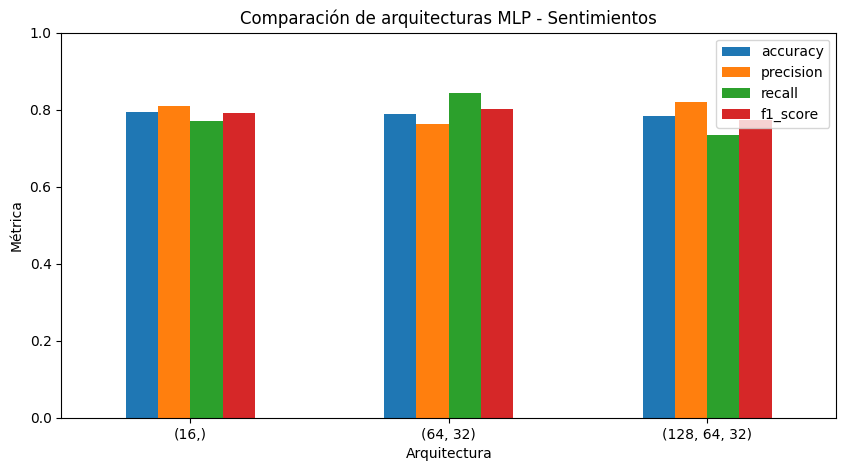

    architecture  accuracy  precision    recall  f1_score
0          (16,)  0.793939   0.810606  0.771635  0.790640
1       (64, 32)  0.789091   0.763043  0.843750  0.801370
2  (128, 64, 32)  0.784242   0.819892  0.733173  0.774112


In [8]:
results_df.plot(
    x='architecture',
    y=['accuracy', 'precision', 'recall', 'f1_score'],
    kind='bar',
    figsize=(10, 5),
)
plt.title('Comparación de arquitecturas MLP - Sentimientos')
plt.xlabel('Arquitectura')
plt.ylabel('Métrica')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

print(results_df)

## 9. Reto - Punto 3 y 4: Probar 10 comentarios nuevos e identificar errores

Se usa la arquitectura con mejor desempeño según la tabla comparativa. Cambia el valor de `mejor_arquitectura` si tu resultado indica otra arquitectura como la mejor.

In [9]:
mejor_arquitectura = '(128, 64, 32)'
mejor_modelo = modelos_entrenados[mejor_arquitectura]

comentarios_nuevos = [
    ("This restaurant exceeded all my expectations", 1),
    ("The delivery was extremely slow and frustrating", 0),
    ("Amazing customer support, very helpful", 1),
    ("The product broke after one day of use", 0),
    ("I really enjoyed this experience", 1),
    ("Worst purchase I have made this year", 0),
    ("The quality is outstanding for the price", 1),
    ("Nothing special, quite forgettable", 0),
    ("Great value and fast shipping", 1),
    ("The screen arrived scratched and damaged", 0),
]

print(f'Probando con arquitectura {mejor_arquitectura}\n')

aciertos = 0
errores = []

for texto, real in comentarios_nuevos:
    limpio = clean_text(texto)
    vector = tfidf.transform([limpio])
    prediccion = mejor_modelo.predict(vector)[0]
    etiqueta = 'Positivo' if prediccion == 1 else 'Negativo'
    esperado = 'Positivo' if real == 1 else 'Negativo'
    correcto = 'OK' if prediccion == real else 'ERROR'

    if prediccion == real:
        aciertos += 1
    else:
        errores.append((texto, esperado, etiqueta))

    print(f'[{correcto}] "{texto}" -> Predicho: {etiqueta} | Esperado: {esperado}')

print(f'\nAciertos: {aciertos}/10')
print(f'\nErrores encontrados: {len(errores)}')
for texto, esperado, predicho in errores:
    print(f'- "{texto}" (esperado: {esperado}, predicho: {predicho})')

Probando con arquitectura (128, 64, 32)

[ERROR] "This restaurant exceeded all my expectations" -> Predicho: Negativo | Esperado: Positivo
[OK] "The delivery was extremely slow and frustrating" -> Predicho: Negativo | Esperado: Negativo
[ERROR] "Amazing customer support, very helpful" -> Predicho: Negativo | Esperado: Positivo
[OK] "The product broke after one day of use" -> Predicho: Negativo | Esperado: Negativo
[OK] "I really enjoyed this experience" -> Predicho: Positivo | Esperado: Positivo
[OK] "Worst purchase I have made this year" -> Predicho: Negativo | Esperado: Negativo
[OK] "The quality is outstanding for the price" -> Predicho: Positivo | Esperado: Positivo
[ERROR] "Nothing special, quite forgettable" -> Predicho: Positivo | Esperado: Negativo
[OK] "Great value and fast shipping" -> Predicho: Positivo | Esperado: Positivo
[OK] "The screen arrived scratched and damaged" -> Predicho: Negativo | Esperado: Negativo

Aciertos: 7/10

Errores encontrados: 3
- "This restaurant exc

## 10. Matriz de confusión del mejor modelo (sobre el set de prueba original)

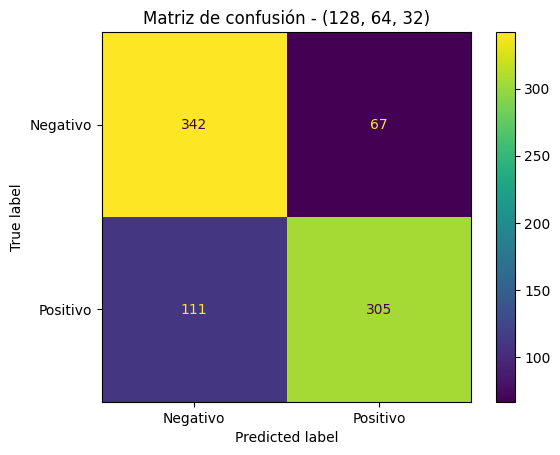

              precision    recall  f1-score   support

    Negativo       0.75      0.84      0.79       409
    Positivo       0.82      0.73      0.77       416

    accuracy                           0.78       825
   macro avg       0.79      0.78      0.78       825
weighted avg       0.79      0.78      0.78       825



In [10]:
pred_mejor = mejor_modelo.predict(X_test_tfidf)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_mejor,
    display_labels=['Negativo', 'Positivo'],
)
plt.title(f'Matriz de confusión - {mejor_arquitectura}')
plt.show()

print(classification_report(y_test, pred_mejor, target_names=['Negativo', 'Positivo']))

## 11. Reto - Punto 5: ¿El modelo entiende el lenguaje o solo reconoce patrones?

El modelo solo reconoce patrones estadísticos de palabras, no comprende el
lenguaje. Esto se evidencia en frases como "Amazing customer support, very
helpful", claramente positiva para cualquier persona, pero que el modelo
clasificó como negativa — probablemente porque palabras como "support"
aparecen en contextos negativos dentro del corpus de entrenamiento (ej.
quejas de servicio al cliente). De igual forma, "Nothing special, quite
forgettable" es una crítica sutil sin palabras negativas explícitas, y el
modelo no logra captar ese matiz porque TF-IDF no entiende sarcasmo, tono
ni contexto, solo cuenta la frecuencia de palabras.